# Guía de Trabajo Práctico 4

**Materia**: Aprendizaje Profundo Basado en la Física (optativa del Instituto Balseiro)

**Docente**: José I. Robledo

**Edición**: abril-mayo 2026

## Física Diferenciable con PyTorch

En esta guía vas a trabajar con simuladores differentiables escritos directamente en PyTorch. La idea central es simple: si la simulación está construida con operaciones diferenciables, entonces podés derivar una función de costo respecto de parámetros físicos, condiciones iniciales o variables de control y usar gradiente descendente para resolver problemas inversos.


---

## Ejercicio 1 — Tiro parabólico y diseño inverso con física diferenciable

Vamos a trabajar con un proyectil 2D lanzado desde el origen. El estado es `(x, y, v_x, v_y)` y usaremos el modelo más simple sin rozamiento:

$$
\dot{x} = v_x, \qquad \dot{y} = v_y,
$$
$$
\dot{v}_x = 0, \qquad \dot{v}_y = -g.
$$

El disparo estará parametrizado por una rapidez inicial `v0` y un ángulo `theta`, de modo que

$$
v_x(0) = v_0 \cos(\theta), \qquad v_y(0) = v_0 \sin(\theta).
$$

Como queremos usar autograd para optimizar `v0` y `theta`, toda la simulación debe implementarse con operaciones diferenciables de PyTorch.

### Tareas

1. Completar `projectile_rollout` para devolver la trayectoria `x(t), y(t)` usando Euler explícito.
2. Simular una trayectoria con `v0 = 15`, `theta = 0.9 rad`, `dt = 0.02`, `steps = 180`.
3. Graficar la trayectoria en el plano `y(x)`.
4. Definir un blanco en `(x_target, y_target) = (18, 6)`.
5. Usar el simulador diferenciable para ajustar `v0` y `theta` de forma que el proyectil pase lo más cerca posible del blanco.
6. Graficar la trayectoria inicial, la trayectoria optimizada y el blanco.

Sugerencias:

- Para asegurar `v0 > 0`, optimizá un parámetro libre `raw_v0` y definí `v0 = softplus(raw_v0)`.
- Para mantener `theta` en un rango razonable, podés usar una sigmoide y reescalarla, por ejemplo al intervalo `(0.05, 1.45)` rad.
- Como la trayectoria tiene longitud fija, conviene definir la loss usando la menor distancia al blanco a lo largo de todos los pasos temporales.


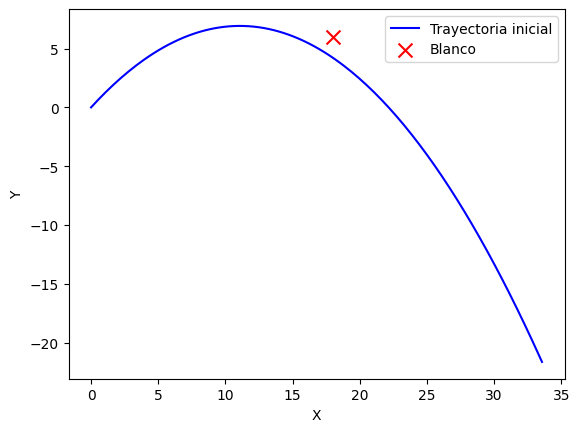

In [5]:
import torch 
import matplotlib.pyplot as plt

def projectile_rollout(v0, theta, dt=0.02, steps=180, g=9.81):
    x = torch.tensor(0.0)
    y = torch.tensor(0.0)
    vx = v0 * torch.cos(theta)
    vy = v0 * torch.sin(theta)

    xs = [x]
    ys = [y]

    for _ in range(steps):
        # TODO: actualizar velocidades con la gravedad
        vy = vy - g * dt
        # TODO: actualizar posiciones
        x = x + vx * dt
        y = y + vy * dt
        # TODO: guardar x, y
        xs.append(x)
        ys.append(y)

    # TODO: devolver tensores xs, ys con shape (steps + 1,)
    return torch.stack(xs), torch.stack(ys)


x_target = torch.tensor(18.0)
y_target = torch.tensor(6.0)


def closest_distance_loss(xs, ys, x_target, y_target):
    # TODO: calcular la distancia cuadratica a cada punto de la trayectoria
    distances = (xs - x_target)**2 + (ys - y_target)**2
    # TODO: devolver el minimo de esas distancias
    return distances.min()


v0_test = torch.tensor(15.0)
theta_test = torch.tensor(0.9)
# TODO: simular la trayectoria inicial y graficarla
xs_test, ys_test = projectile_rollout(v0_test, theta_test)
plt.plot(xs_test, ys_test, 'b-', label='Trayectoria inicial')
plt.scatter(x_target, y_target, c='r', marker='x', s=100, label='Blanco')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()


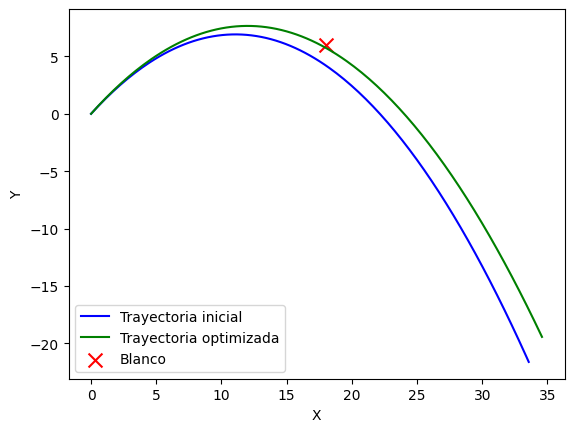

In [9]:
raw_v0 = torch.tensor(2.0, requires_grad=True)
raw_theta = torch.tensor(0.0, requires_grad=True)
optimizer = torch.optim.Adam([raw_v0, raw_theta], lr=0.05)
history = []

for epoch in range(400):
    # TODO: parametrizar v0 y theta
    # parametrizar v0 con softplus para que sea positivo, y theta con sigmoid para que esté entre 0 y pi/2
    v0 = torch.nn.functional.softplus(raw_v0)
    theta = torch.sigmoid(raw_theta) * (torch.pi / 2)
    # TODO: simular la trayectoria
    xs, ys = projectile_rollout(v0, theta)
    # TODO: definir la loss respecto del blanco
    loss = closest_distance_loss(xs, ys, x_target, y_target)
    # TODO: hacer backward y optimizer.step()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# TODO: reconstruir trayectoria final y compararla con la inicial
v0_final = torch.nn.functional.softplus(raw_v0)
theta_final = torch.sigmoid(raw_theta) * (torch.pi / 2)
xs_final, ys_final = projectile_rollout(v0_final, theta_final)
plt.plot(xs_test, ys_test, 'b-', label='Trayectoria inicial')
plt.plot(xs_final.detach(), ys_final.detach(), 'g-', label='Trayectoria optimizada')
plt.scatter(x_target, y_target, c='r', marker='x', s=100, label='Blanco')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()


---

## Ejercicio 2 — Inferencia del amortiguamiento a partir de datos

Para centrarnos en la física diferenciable, volvamos ahora al oscilador amortiguado 1D con masa unitaria y ecuación

$$
\ddot{x}(t) + c\,\dot{x}(t) + k\,x(t) = 0,
$$

donde `k` es la constante del resorte y `c` el coeficiente de amortiguamiento.

Usaremos un esquema de Euler semiimplícito:

$$
v_{n+1} = v_n + \Delta t\,(-k x_n - c v_n), \qquad
x_{n+1} = x_n + \Delta t\, v_{n+1}.
$$

Supongamos ahora que mediste una trayectoria `x_obs(t)` y querés estimar el valor de `c`. Vamos a generar primero una trayectoria sintética con un valor verdadero `c_true` y luego vamos a recuperar ese parámetro minimizando el error cuadrático medio entre la trayectoria observada y la simulada.

### Tareas

1. Completar `oscillator_step` y `simulate_oscillator`.
2. Construir `x_obs` usando `c_true = 0.18`.
3. Introducir ruido gaussiano pequeño para volver el problema un poco más realista.
4. Definir un parámetro libre `raw_c` y parametrizar el amortiguamiento como `c_hat = softplus(raw_c)` para asegurar positividad.
5. Optimizar `raw_c` con Adam.
6. Graficar la historia de la loss y comparar `x_obs(t)` con la trayectoria reconstruida.


In [17]:
def oscillator_step(x, v, k, c, dt):
    # TODO: calcular la aceleracion a = -k * x - c * v
    a = -k * x - c * v
    # TODO: actualizar velocidad con Euler
    v_new = v + a * dt
    # TODO: actualizar posicion usando la nueva velocidad
    x_new = x + v_new * dt
    return x_new, v_new

def simulate_oscillator(x0, v0, k, c, dt, steps):
    xs = [x0]
    vs = [v0]
    x, v = x0, v0
    for _ in range(steps):
        # TODO: avanzar un paso de tiempo con oscillator_step
        x, v = oscillator_step(x, v, k, c, dt)
        # TODO: append de los nuevos estados
        xs.append(x)
        vs.append(v)
    # TODO: devolver tensores apilados con shape (steps + 1,)
    return torch.stack(xs), torch.stack(vs)


x0 = torch.tensor(1.0)
v0 = torch.tensor(0.0)
k = torch.tensor(1.5)
dt = 0.05
steps = 200
c_true = torch.tensor(0.18)
noise_std = 0.01

with torch.no_grad():
    # TODO: generar trayectoria observada libre de ruido
    x_obs, v_obs = simulate_oscillator(x0, v0, k, c_true, dt, steps)
    # TODO: sumar ruido gaussiano pequeno a la posicion observada
    x_obs = x_obs + torch.randn_like(x_obs) * noise_std


Text(0, 0.5, 'Velocidad')

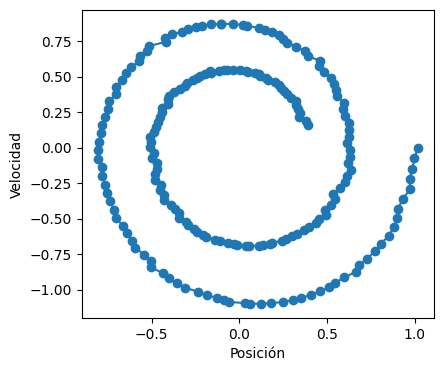

In [18]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(x_obs, v_obs, 'o-', label='Observado')
plt.xlabel('Posición')
plt.ylabel('Velocidad')


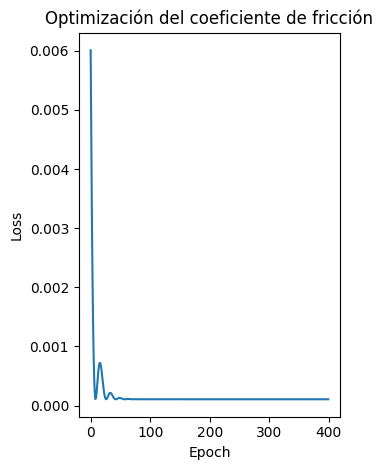

In [16]:

raw_c = torch.tensor(-2.0, requires_grad=True)
optimizer = torch.optim.Adam([raw_c], lr=0.05)
loss_history = []

for epoch in range(400):
    # TODO: convertir raw_c en c_hat usando softplus
    c_hat = torch.nn.functional.softplus(raw_c)
    # TODO: simular con c_hat
    x_sim, v_sim = simulate_oscillator(x0, v0, k, c_hat, dt, steps)
    # TODO: definir loss MSE contra x_obs
    loss = torch.mean((x_sim - x_obs)**2)
    # TODO: hacer backward y step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

# TODO: reconstruir la mejor trayectoria y graficar resultados
plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Optimización del coeficiente de fricción')
plt.tight_layout()
plt.show()



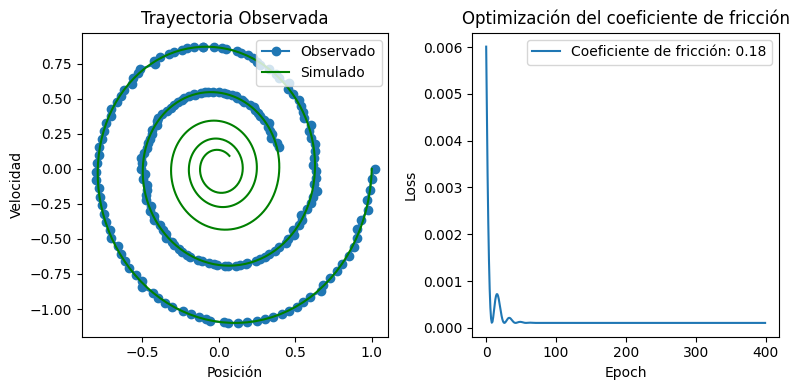

In [22]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend([r"Coeficiente de fricción: {:.2f}".format(c_hat.item())])
plt.title('Optimización del coeficiente de fricción')
plt.subplot(1, 2, 1)
plt.plot(x_obs, v_obs, 'o-', label='Observado')
plt.plot(x_sim.detach(), v_sim.detach(), 'g-', label='Simulado')
plt.xlabel('Posición')
plt.ylabel('Velocidad')
plt.title('Trayectoria Observada')
plt.legend()
plt.tight_layout()
plt.show()

---

## Ejercicio 3 — Sensibilidad respecto de condiciones iniciales y parámetros

En física diferenciable no sólo interesa ajustar parámetros: también importa entender **qué tan sensible** es una cantidad de interés ante pequeños cambios en las entradas del simulador.

Tomemos como observable la posición final `x(T)` del oscilador luego de `T = steps * dt`.

1. Repetir la simulación con `x0` como tensor con `requires_grad=True`.
2. Calcular `\partial x(T) / \partial x0` usando autograd.
3. Repetir el experimento con `c` como tensor con `requires_grad=True` y calcular `\partial x(T) / \partial c`.
4. Comparar ambas derivadas en valor absoluto e interpretar cuál variable parece más influyente para este horizonte temporal.
5. Bonus: cambiar el observable por la energía final aproximada `E(T) = 0.5 * (v(T)^2 + k x(T)^2)` y repetir el análisis.

Este tipo de derivadas es útil para diseño de experimentos, calibración e identificación de parámetros.


In [29]:
x0_sens = torch.tensor(1.0, requires_grad=True)
c_sens = torch.tensor(0.15, requires_grad=True)
k_sens = torch.tensor(1.5)

# TODO: simular con x0_sens y obtener gradiente de x(T) respecto de x0_sens
x, v = simulate_oscillator(x0_sens, v0, k_sens, c_sens, dt, steps)
X_T = x[-1]
print("Valor de x(T):", X_T.item())
X_T.backward()
print("Sensibilidad de x(T) respecto de x0:", x0_sens.grad.item())
# TODO: simular con c_sens y obtener gradiente de x(T) respecto de c_sens
print("Sensibilidad de x(T) respecto de c:", c_sens.grad.item())
# TODO: imprimir ambas sensibilidades y discutir el resultado


Valor de x(T): 0.4430409073829651
Sensibilidad de x(T) respecto de x0: 0.44304099678993225
Sensibilidad de x(T) respecto de c: -2.317201852798462


AttributeError: 'NoneType' object has no attribute 'item'

---

## Ejercicio 4 — Circuito RC como sistema diferenciable

Consideremos un circuito RC serie excitado por una fuente constante `V_in`. Si elegimos como variable de estado la tensión del capacitor `V_c(t)`, el modelo viene dado por

$$
C \, \dot{V}_c = \frac{V_{in} - V_c}{R},
\qquad \Rightarrow \qquad
\dot{V}_c = \frac{V_{in} - V_c}{RC}.
$$

Este sistema es útil para física diferenciable porque:

- tiene una dinámica simple pero no trivial;
- permite plantear **inferencia de parámetros**;
- permite estudiar **sensibilidad** respecto de `R`, `C` y la condición inicial.

1. Completar `rc_step` y `simulate_rc`.
2. Simular la carga del capacitor con `R = 2`, `C = 1.5`, `V_in = 5`, `V0 = 0`, `dt = 0.05`, `steps = 120`.
3. Graficar `V_c(t)`.
4. Generar datos sintéticos `V_obs(t)` con un valor verdadero `R_true`, agregando ruido pequeño.
5. Inferir `R` minimizando el MSE entre `V_obs(t)` y la trayectoria simulada.
6. Calcular con autograd las sensibilidades `\partial V_c(T)/\partial R` y `\partial V_c(T)/\partial C`.

Preguntas para discutir:

- ¿Qué parámetro parece afectar más el voltaje final?
- ¿Cómo cambia la dificultad de inferir `R` si el horizonte temporal es muy corto?
- ¿Qué interpretación física tiene la combinación `RC` en este problema?


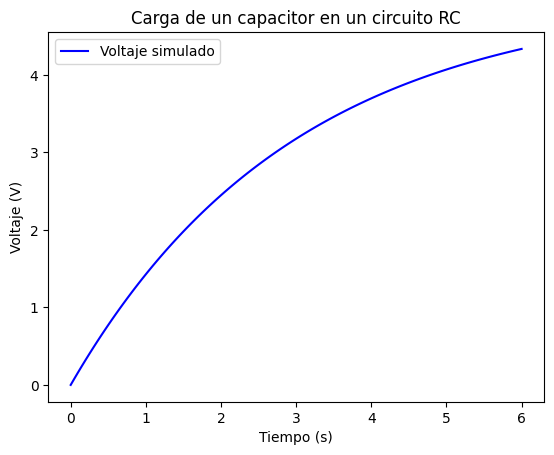

In [40]:
def rc_step(vc, R, C, V_in, dt):
    # TODO: calcular dVc/dt = (V_in - vc) / (R * C)
    dvc_dt = (V_in - vc) / (R * C)
    # TODO: actualizar vc con Euler
    vc = vc + dvc_dt * dt
    return vc


def simulate_rc(V0, R, C, V_in, dt, steps):
    vcs = [V0]
    vc = V0
    for _ in range(steps):
        # TODO: avanzar un paso con rc_step
        vc = rc_step(vc, R, C, V_in, dt)
        # TODO: guardar el nuevo voltaje
        vcs.append(vc)
    # TODO: devolver la trayectoria completa
    return torch.stack(vcs)


V0 = torch.tensor(0.0)
R = torch.tensor(2.0)
C = torch.tensor(1.5)
V_in = torch.tensor(5.0)
dt = 0.05
steps = 120
t = torch.linspace(0.0, steps * dt, steps + 1)

# TODO: simular y graficar la carga del capacitor
vcs_sim = simulate_rc(V0, R, C, V_in, dt, steps)
plt.plot(t, vcs_sim, 'b-', label='Voltaje simulado')
plt.xlabel('Tiempo (s)')
plt.ylabel('Voltaje (V)')
plt.title('Carga de un capacitor en un circuito RC')
plt.legend()
plt.show()

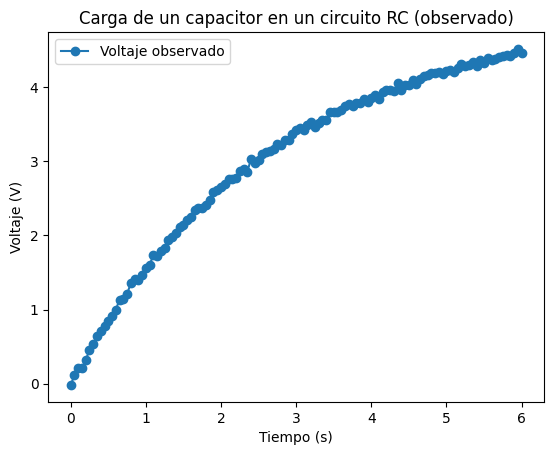

In [35]:

R_true = torch.tensor(1.8)
noise_std = 0.03

with torch.no_grad():
    # TODO: generar trayectoria observada con ruido
    vcs_obs = simulate_rc(V0, R_true, C, V_in, dt, steps)
    vcs_obs = vcs_obs + torch.randn_like(vcs_obs) * noise_std
    
plt.plot(t, vcs_obs, 'o-', label='Voltaje observado')
plt.xlabel('Tiempo (s)')
plt.ylabel('Voltaje (V)')
plt.title('Carga de un capacitor en un circuito RC (observado)')
plt.legend()
plt.show()


In [36]:

raw_R = torch.tensor(0.0, requires_grad=True)
optimizer = torch.optim.Adam([raw_R], lr=0.05)
loss_history = []

for epoch in range(300):
    # TODO: parametrizar R_hat con softplus
    R_hat = torch.nn.functional.softplus(raw_R)
    # TODO: simular el circuito
    vcs_sim = simulate_rc(V0, R_hat, C, V_in, dt, steps)
    # TODO: definir la loss MSE y optimizar
    loss = torch.mean((vcs_sim - vcs_obs)**2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

R_hat_final = torch.nn.functional.softplus(raw_R)
print("Valor estimado de R:", R_hat_final.item())


Valor estimado de R: 1.800162672996521


Sensibilidad de Vc(T) respecto de R: -0.667522132396698
Sensibilidad de Vc(T) respecto de C: -0.8011003136634827


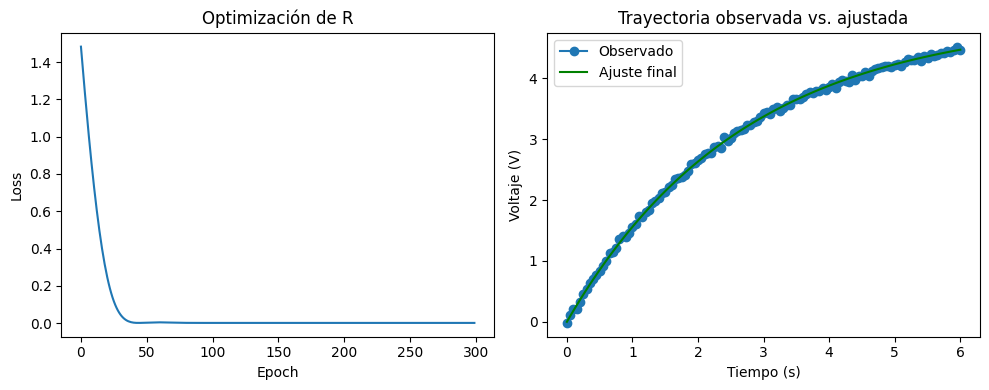

In [39]:

# Recalcular una trayectoria fresca para no reutilizar un grafo ya liberado
R_eval = torch.tensor(R_hat_final.item(), requires_grad=True)
C_eval = torch.tensor(C.item(), requires_grad=True)
vcs_fit = simulate_rc(V0, R_eval, C_eval, V_in, dt, steps)

# Sensibilidades de Vc(T) respecto de R y C
dVc_dR = torch.autograd.grad(vcs_fit[-1], R_eval, retain_graph=True)[0]
dVc_dC = torch.autograd.grad(vcs_fit[-1], C_eval, retain_graph=True)[0]
print("Sensibilidad de Vc(T) respecto de R:", dVc_dR.item())
print("Sensibilidad de Vc(T) respecto de C:", dVc_dC.item())

# Graficar historia de la loss y ajuste final
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Optimización de R')
plt.subplot(1, 2, 2)
plt.plot(t, vcs_obs, 'o-', label='Observado')
plt.plot(t, vcs_fit.detach(), 'g-', label='Ajuste final')
plt.xlabel('Tiempo (s)')
plt.ylabel('Voltaje (V)')
plt.title('Trayectoria observada vs. ajustada')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Estimar R para distintos horizontes temporales T y discutir cómo cambia la sensibilidad
T_values = [1.0, 3.0, 5.0]  # segundos
raw_R = torch.tensor(0.0, requires_grad=True)
for T in T_values:
    steps_T = int(T / dt)
    hat_R = torch.nn.functional.softplus(raw_R)
    vcs_sim_T = simulate_rc(V0, hat_R, C, V_in, dt, steps_T)
    

---

## Ejercicio 5 -  FD + NN para controlar un circuito RC

En los ejercicios anteriores, la física diferenciable se usó para ajustar **parámetros físicos** como `R` o condiciones de disparo como `v0` y `theta`. Ahora queremos mostrar una idea complementaria: usar una **red neuronal como controlador**, mientras la evolución temporal del sistema sigue estando dada por la física conocida.

El circuito sigue siendo el mismo:

$$
\dot{V}_c = \frac{V_{in} - V_c}{RC}.
$$

Pero en vez de fijar `V_in` de antemano, vamos a hacer que una red neuronal la produzca en cada paso de tiempo:

$$
V_{in}(t) = \mathrm{NN}_\theta\big(V_c(t), V_{\mathrm{target}}\big).
$$

### Intención física del problema

La idea no es “que la red aprenda la física del capacitor”. Esa parte ya la conocemos. La intención es otra:

- el **simulador físico** se encarga de imponer la dinámica correcta del circuito;
- la **red neuronal** actúa como un controlador que decide qué tensión aplicar;
- la función de costo mide si el capacitor llega al valor deseado y cuánta acción de control fue necesaria.

Esto ilustra bien la lógica FD + NN: la red propone acciones; la física diferenciable calcula sus consecuencias a lo largo del tiempo; `backward()` ajusta los pesos de la red a partir del objetivo final.


1. Implementar una red pequeña que reciba `V_c` y `V_target` y devuelva `V_in`.
2. Implementar `simulate_rc_controlled`.
3. Entrenar la red para llevar el capacitor desde `V0 = 0` hasta `V_target = 4`.
4. Penalizar también señales de control excesivamente grandes.
5. Graficar la evolución de `V_c(t)` y de `V_in(t)`.

Sugerencia para la loss:

$$
\mathcal{L} = \frac{1}{T}\sum_t (V_c(t)-V_{\text{target}})^2 + \lambda \frac{1}{T}\sum_t V_{in}(t)^2.
$$


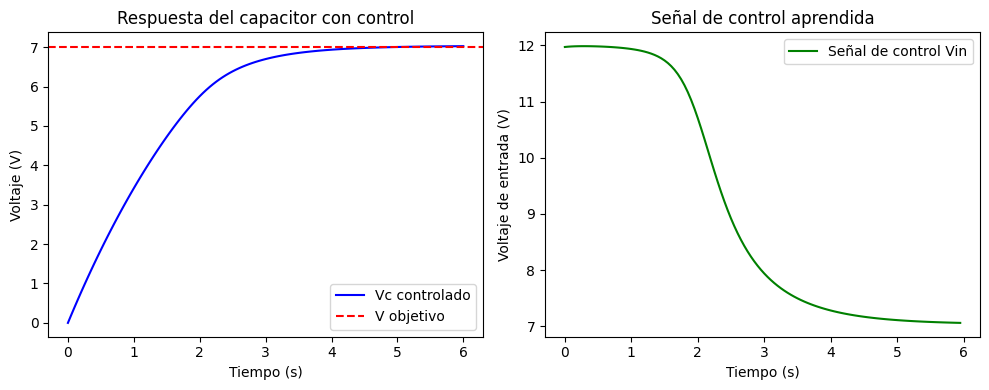

In [43]:
import torch
from torch import nn

class RCController(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
        )

    def forward(self, vc, v_target):
        # TODO: concatenar vc y v_target como entrada
        input = torch.stack([vc, v_target])
        # TODO: devolver un escalar de control V_in
        V_in = self.net(input)
        return V_in.squeeze()


def simulate_rc_controlled(V0, R, C, controller, v_target, dt, steps):
    vc = V0
    vcs = [vc]
    vins = []

    for _ in range(steps):
        # TODO: pedirle a la red la tension de entrada
        V_in = controller(vc, v_target)
        # TODO: avanzar la dinamica del capacitor
        vc = rc_step(vc, R, C, V_in, dt)
        # TODO: guardar Vc y Vin
        vcs.append(vc)
        vins.append(V_in)

    # TODO: devolver trayectorias completas
    return torch.stack(vcs), torch.stack(vins)


V0 = torch.tensor(0.0)
R = torch.tensor(2.0)
C = torch.tensor(1.5)
v_target = torch.tensor(7.0)
dt = 0.05
steps = 120
lambda_u = 1e-2

controller = RCController()
optimizer = torch.optim.Adam(controller.parameters(), lr=1e-3)
history = []

for epoch in range(600):
    # TODO: simular el sistema controlado
    vcs, vins = simulate_rc_controlled(V0, R, C, controller, v_target, dt, steps)
    # TODO: definir loss de seguimiento + regularizacion del control
    tracking_loss = torch.mean((vcs - v_target)**2)
    reg_loss = lambda_u * torch.mean(vins**2)
    loss = tracking_loss + reg_loss
    # TODO: hacer backward y optimizer.step()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# TODO: graficar trayectoria de Vc y señal Vin
import matplotlib.pyplot as plt
t = torch.linspace(0.0, steps * dt, steps + 1)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t, vcs.detach(), 'b-', label='Vc controlado')
plt.axhline(v_target.item(), color='r', linestyle='--', label='V objetivo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Voltaje (V)')
plt.title('Respuesta del capacitor con control')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(t[:-1], vins.detach(), 'g-', label='Señal de control Vin')
plt.xlabel('Tiempo (s)')
plt.ylabel('Voltaje de entrada (V)')
plt.title('Señal de control aprendida')
plt.legend()
plt.tight_layout()
plt.show()
